## Dataset: MNIST or CIFAR-10 

- **MNIST**: 28×28 grayscale digits (fast, good for debugging ideas)
- **CIFAR-10**: 32×32 color images across 10 classes (harder, more realistic)

The dataset is selectable via the config variable. The baseline model and EDA should work for both.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as T
from tqdm.auto import tqdm

@dataclass
class CFG:
    dataset: str = "mnist"   # "mnist" or "cifar10" 
    data_dir: str = "./data"
    batch_size: int = 128    # chunk of data to be fed to the model each epoch
    num_workers: int = 2     # number of workers fetching the dataset
    val_frac: float = 0.1    # fraction of the dataset for validation

    epochs: int = 15         # number of training epochs
    lr: float = 1e-3         # learning rate
    weight_decay: float = 5e-4
    seed: int = 42

    quick_run: bool = False  # set true to run a quick smoke test
    quick_train_size: int = 8000 # set size of the dataset used for smoketest

cfg = CFG()

def seed_everything(seed=1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # speed
    torch.backends.cudnn.deterministic = False

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(cfg)


Device: cpu
CFG(dataset='mnist', data_dir='./data', batch_size=128, num_workers=2, val_frac=0.1, epochs=15, lr=0.001, weight_decay=0.0005, seed=42, quick_run=False, quick_train_size=8000)


c:\Users\sungs\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data
- normalization (always)
- mild augmentation for CIFAR-10 (random crop + flip)

Normalization stabilizes training, while augmentation is tipically introduced to reduce overfitting and improve generalization.


In [2]:
def get_dataset(cfg: CFG):
    name = cfg.dataset.lower()
    if name == "mnist":
        num_classes = 10
        in_channels = 1
        class_names = [str(i) for i in range(10)]
        image_shape = (1, 28, 28)

        tf_train = T.Compose([
            T.ToTensor(),
            T.Normalize((0.1307,), (0.3081,))
        ])
        tf_test = tf_train

        train_full = torchvision.datasets.MNIST(cfg.data_dir, train=True, download=True, transform=tf_train)
        test = torchvision.datasets.MNIST(cfg.data_dir, train=False, download=True, transform=tf_test)

        denorm = lambda x: (x * 0.3081 + 0.1307).clamp(0, 1)

    elif name == "cifar10":
        num_classes = 10
        in_channels = 3
        class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
        image_shape = (3, 32, 32)

        mean = (0.4914, 0.4822, 0.4465)
        std  = (0.2470, 0.2435, 0.2616)

        tf_train = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
        tf_test = T.Compose([
            T.ToTensor(),
            T.Normalize(mean, std),
        ])

        train_full = torchvision.datasets.CIFAR10(cfg.data_dir, train=True, download=True, transform=tf_train)
        test = torchvision.datasets.CIFAR10(cfg.data_dir, train=False, download=True, transform=tf_test)

        def denorm(x):
            mean_t = torch.tensor(mean, device=x.device).view(1,3,1,1)
            std_t  = torch.tensor(std,  device=x.device).view(1,3,1,1)
            return (x * std_t + mean_t).clamp(0, 1)

    else:
        raise ValueError("cfg.dataset must be 'mnist' or 'cifar10'")

    return train_full, test, num_classes, in_channels, class_names, image_shape, denorm

train_full, testset, K, C, class_names, image_shape, denorm = get_dataset(cfg)

# Optional quick run for smoke test
if cfg.quick_run:
    idxs = torch.randperm(len(train_full))[:cfg.quick_train_size].tolist()
    train_full = torch.utils.data.Subset(train_full, idxs)

n_total = len(train_full)
n_val = int(cfg.val_frac * n_total)
n_train = n_total - n_val

trainset, valset = random_split(
    train_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_loader = DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader   = DataLoader(valset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(testset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print("Train/Val/Test sizes:", len(trainset), len(valset), len(testset))
print("Classes:", K, "| In channels:", C, "| Shape:", image_shape)


Train/Val/Test sizes: 54000 6000 10000
Classes: 10 | In channels: 1 | Shape: (1, 28, 28)


## EDA / diagnostics
I'll analyze class balance, sample images and perform some basic sanity checks on shapes and ranges for the images.


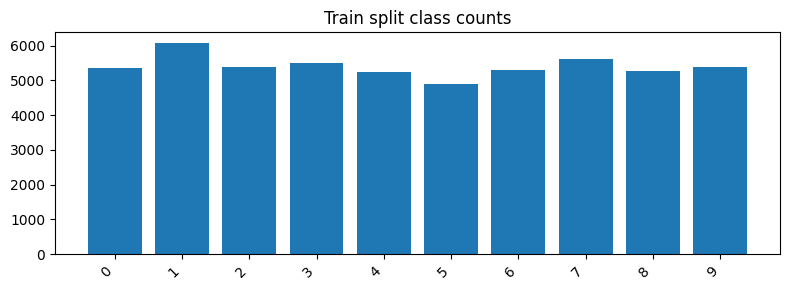

Min/Max class count: 4903 6076


In [3]:
def get_labels_from_subset(subset):
    if isinstance(subset, torch.utils.data.Subset):
        ds = subset.dataset
        idxs = subset.indices
        labels = []
        for i in idxs:
            _, y = ds[i]
            labels.append(int(y))
        return np.array(labels)
    else:
        return np.array([int(subset[i][1]) for i in range(len(subset))])

train_labels = get_labels_from_subset(trainset)
counts = np.bincount(train_labels, minlength=K)

plt.figure(figsize=(8,3))
plt.bar(range(K), counts)
plt.xticks(range(K), class_names, rotation=45, ha="right")
plt.title("Train split class counts")
plt.tight_layout()
plt.show()

print("Min/Max class count:", counts.min(), counts.max())


### Visual inspection
Visually check whether labels look plausible, normalization isn't broken and transforms for augmentation are implemented correctly.



c:\Users\sungs\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


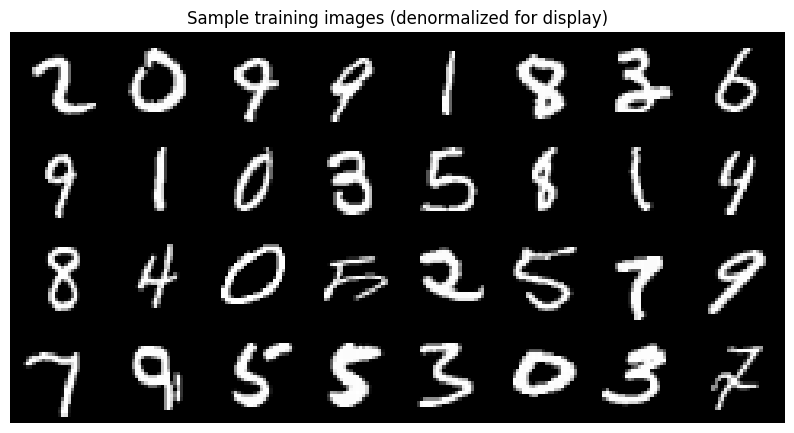

Sample labels: ['2', '0', '9', '9', '1', '8', '3', '6', '9', '1', '0', '3', '5', '8', '1', '4']
Batch tensor shape: torch.Size([128, 1, 28, 28])
Batch min/max: -0.4242129623889923 2.821486711502075


In [4]:
xb, yb = next(iter(train_loader))
xb_vis = xb[:32].to(device)

# denormalize for viewing
xb_vis = denorm(xb_vis)

grid = torchvision.utils.make_grid(xb_vis.cpu(), nrow=8)
plt.figure(figsize=(10,6))
plt.imshow(grid.permute(1,2,0).numpy())
plt.axis("off")
plt.title("Sample training images (denormalized for display)")
plt.show()

print("Sample labels:", [class_names[int(i)] for i in yb[:16].tolist()])
print("Batch tensor shape:", xb.shape)
print("Batch min/max:", xb.min().item(), xb.max().item())


## Traditional Classification model: Baseline CNN
We’ll use a small Convolutional Neural Network (CNN, a staple in image-related tasks) with a feature extractor + classification head architecture.

Feature extractor:
- convolution blocks
- batch norm
- pooling
  
Classification head:
- a small Multilayer Perceptron 


In [5]:
class BaselineCNN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, width: int = 64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, width, 3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(width, width*2, 3, padding=1),
            nn.BatchNorm2d(width*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(width*2, width*4, 3, padding=1),
            nn.BatchNorm2d(width*4),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width*4, width*4),
            nn.ReLU(inplace=True),
            nn.Linear(width*4, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)  # logits

model = BaselineCNN(C, K).to(device)
print(model) # check model architecture


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (

## Training utilities
We’ll track:
- loss (cross-entropy, in our baseline)
- accuracy

In [6]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for xb, yb in tqdm(loader, desc="train", leave=False):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, yb) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, yb) * bs
        n += bs

    return total_loss / n, total_acc / n

def predict_proba(model, loader):
    """Returns probs [N,K], y [N] for downstream analysis."""
    model.eval()
    probs_list, y_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = F.softmax(logits, dim=1).cpu()
            probs_list.append(probs)
            y_list.append(yb)
    return torch.cat(probs_list, dim=0), torch.cat(y_list, dim=0)


## Run Training on the baseline
We’ll train for a few epochs, keep the best model by validation accuracy, then evaluate on the held-out test set.

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

history = []
best_val_acc = -1.0
best_state = None

for epoch in range(cfg.epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_acc = evaluate(model, val_loader)

    history.append((epoch, tr_loss, tr_acc, va_loss, va_acc))
    print(f"epoch={epoch:02d}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
te_loss, te_acc = evaluate(model, test_loader)
print(f"\nBest val_acc={best_val_acc:.4f} | Test acc={te_acc:.4f} | Test loss={te_loss:.4f}")


epoch=00  train_loss=0.2693 train_acc=0.9239  val_loss=1.1784 val_acc=0.6325


epoch=01  train_loss=0.0628 train_acc=0.9812  val_loss=0.1816 val_acc=0.9405


epoch=02  train_loss=0.0430 train_acc=0.9870  val_loss=0.2126 val_acc=0.9362


epoch=03  train_loss=0.0332 train_acc=0.9896  val_loss=0.3750 val_acc=0.8980


epoch=04  train_loss=0.0258 train_acc=0.9919  val_loss=0.0463 val_acc=0.9870


...

epoch=11  train_loss=0.0112 train_acc=0.9963  val_loss=0.0348 val_acc=0.9905


epoch=12  train_loss=0.0120 train_acc=0.9961  val_loss=0.0720 val_acc=0.9770


epoch=13  train_loss=0.0073 train_acc=0.9974  val_loss=0.0438 val_acc=0.9870


epoch=14  train_loss=0.0090 train_acc=0.9969  val_loss=0.0538 val_acc=0.9872



Best val_acc=0.9905 | Test acc=0.9875 | Test loss=0.0415


### Learning curves
Plots of the evolution of the metrics can help diagnose underfitting (both accuracies low), overfitting (train >> val), and/or instabilities (loss spikes).


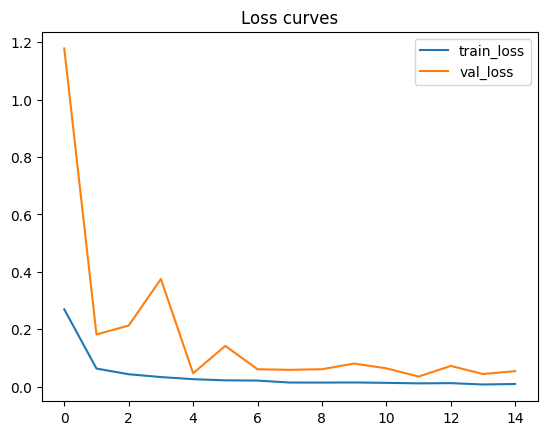

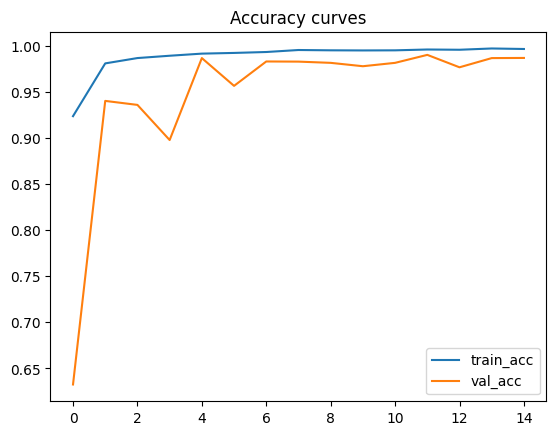

In [8]:
hist = np.array(history)
epochs = hist[:,0]
tr_loss, tr_acc, va_loss, va_acc = hist[:,1], hist[:,2], hist[:,3], hist[:,4]

plt.figure()
plt.plot(epochs, tr_loss, label="train_loss")
plt.plot(epochs, va_loss, label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure()
plt.plot(epochs, tr_acc, label="train_acc")
plt.plot(epochs, va_acc, label="val_acc")
plt.legend()
plt.title("Accuracy curves")
plt.show()


## Investigations with the trained baseline
In order to diagnose the model state and to better understand its failure modes, we’ll examine:
- confusion matrix
- confidence distribution
- most confident mistakes
- a grid of misclassified examples


In [9]:
probs_test, y_test = predict_proba(model, test_loader)
conf, pred = probs_test.max(dim=1)
correct = (pred == y_test)

print("Test accuracy (recomputed):", correct.float().mean().item())
print("Mean confidence (correct):", conf[correct].mean().item())
print("Mean confidence (wrong):  ", conf[~correct].mean().item())

# Show top-10 most confident wrong predictions
wrong_idx = torch.where(~correct)[0]
if len(wrong_idx) > 0:
    top = wrong_idx[torch.argsort(conf[wrong_idx], descending=True)[:10]]
    print("\nMost confident wrong predictions:")
    for i in top.tolist():
        print(f" idx={i:5d}  true={class_names[int(y_test[i])]:>10s}  pred={class_names[int(pred[i])]:>10s}  conf={conf[i].item():.3f}")
else:
    print("No wrong predictions found (unlikely but possible in tiny quick runs).")


Test accuracy (recomputed): 0.987500011920929
Mean confidence (correct): 0.9964143633842468
Mean confidence (wrong):   0.7797460556030273

Most confident wrong predictions:
 idx= 9729  true=         5  pred=         6  conf=1.000
 idx= 6576  true=         7  pred=         1  conf=1.000
 idx= 9698  true=         6  pred=         1  conf=0.999
 idx= 4699  true=         6  pred=         1  conf=0.999
 idx=  582  true=         8  pred=         2  conf=0.999
 idx= 2130  true=         4  pred=         9  conf=0.999
 idx= 3534  true=         4  pred=         8  conf=0.999
 idx=  947  true=         8  pred=         9  conf=0.999
 idx= 1299  true=         5  pred=         7  conf=0.998
 idx= 6559  true=         4  pred=         7  conf=0.997


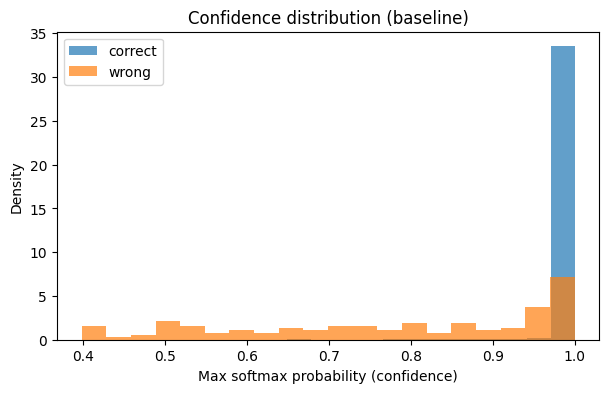

In [10]:
plt.figure(figsize=(7,4))
plt.hist(conf[correct].numpy(), bins=20, alpha=0.7, label="correct", density = True)
plt.hist(conf[~correct].numpy(), bins=20, alpha=0.7, label="wrong", density = True)
plt.xlabel("Max softmax probability (confidence)")
plt.ylabel("Density")
plt.title("Confidence distribution (baseline)")
plt.legend()
plt.show()


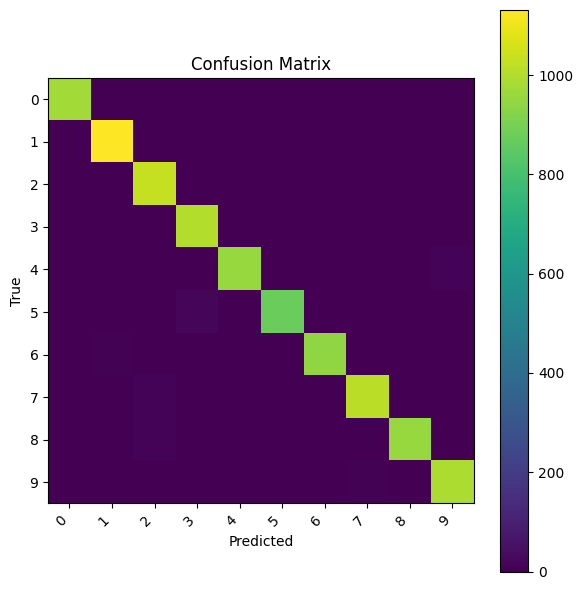

         0: 0.996
         1: 0.996
         2: 0.999
         3: 0.992
         4: 0.973
         5: 0.978
         6: 0.986
         7: 0.986
         8: 0.983
         9: 0.983


In [11]:
cm = torch.zeros(K, K, dtype=torch.int64)
for t, p in zip(y_test, pred):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(6,6))
plt.imshow(cm.numpy())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(K), class_names, rotation=45, ha="right")
plt.yticks(range(K), class_names)
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_acc = cm.diag().float() / cm.sum(dim=1).clamp(min=1).float()
for i, a in enumerate(per_class_acc.tolist()):
    print(f"{class_names[i]:>10s}: {a:.3f}")


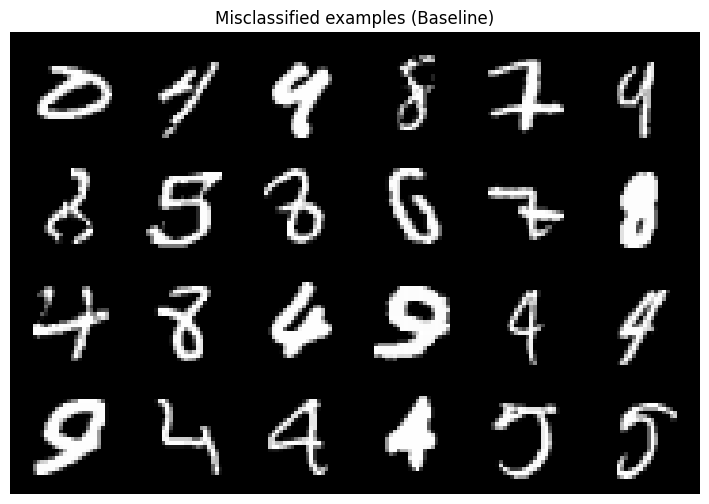

Example titles (first few):
T:0
P:2
C:0.71
T:4
P:7
C:0.99
T:4
P:9
C:1.00
T:8
P:5
C:0.82
T:7
P:2
C:0.86
T:4
P:9
C:0.50


In [12]:
# Grab a subset of misclassified examples and visualize
mis_idx = torch.where(~correct)[0]
n_show = min(24, len(mis_idx))

if n_show == 0:
    print("No misclassified samples to display.")
else:
    show_idx = mis_idx[torch.randperm(len(mis_idx))[:n_show]]

    # fetch images from testset directly (so we can re-denormalize cleanly)
    # Note: testset[i] returns transformed tensor and label; we denorm tensor.
    imgs, titles = [], []
    for i in show_idx.tolist():
        x, y = testset[i]
        imgs.append(x.unsqueeze(0))
        titles.append(f"T:{class_names[y]}\nP:{class_names[int(pred[i])]}\nC:{conf[i].item():.2f}")

    xbatch = torch.cat(imgs, dim=0).to(device)
    xvis = denorm(xbatch).cpu()

    grid = torchvision.utils.make_grid(xvis, nrow=6)
    plt.figure(figsize=(12,6))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.axis("off")
    plt.title("Misclassified examples (Baseline)")
    plt.show()

    print("Example titles (first few):")
    print("\n".join(titles[:6]))


## Bayesian Neural Network: Monte Carlo (MC) Dropout

### Idea
MC Dropout treats dropout at test time as a simple approximation to Bayesian model averaging.

We train a standard classifier with dropout layers. At inference, we keep dropout enabled and run the model multiple times, producing a set of stochastic predictions for the same input $x$.

For one input $x$:
- Run $T$ stochastic forward passes (each uses a different dropout mask)
- Each pass produces logits $z^{(t)}(x)\in\mathbb{R}^K$ and class probabilities
  $$
  \pi^{(t)}(x) = \text{softmax}(z^{(t)}(x)) \in \Delta^{K-1}
  $$
- Estimate the predictive mean probability vector by averaging:
  $$
  \widehat{\bar{\pi}}(x) = \frac{1}{T}\sum_{t=1}^T \pi^{(t)}(x)
  $$
- Compute:
   $$
   \widehat{H}_{\text{pred}}(x),\quad
   \widehat{H}_{\text{exp}}(x),\quad
   \widehat{I}(x)=\widehat{H}_{\text{pred}}(x)-\widehat{H}_{\text{exp}}(x)
   $$
- Compare these uncertainty scores against baseline softmax confidence, especially on incorrect predictions.
  

### Goals
Implement MC Dropout end-to-end and compare against the baseline:
- define a dropout-enabled model (dropout placed in sensible locations)
- train it normally (same training loop as baseline)
- implement MC inference (run $T$ stochastic passes at inference)
- implement uncertainty summaries (predictive entropy, expected entropy, mutual information)
- evaluate:
  - baseline softmax confidence vs MC uncertainty
  - uncertainty histograms (correct vs wrong)
  - “most uncertain examples”
  - confusion matrix conditioned on uncertainty thresholds (e.g., only samples with MI below some cutoff)

---

### Predictive distribution 
For $K$-class classification, a neural network with parameters $\theta$ defines a categorical predictive distribution:
$$
p(y\mid x,\theta) = \text{Cat}(y;\pi_\theta(x))
$$
where $\pi_\theta(x)$ is the softmax probability vector output by the network.

In Bayesian learning we care about the posterior predictive distribution:
$$
p(y\mid x,\mathcal{D}) = \int p(y\mid x,\theta)\,p(\theta\mid\mathcal{D})\,d\theta
$$
which averages predictions over parameter values weighted by the posterior given data $\mathcal{D}$.

MC Dropout approximates this by using dropout to define an approximate posterior $q(\theta)$ and sampling:
- sample $T$ dropout masks $\Rightarrow$ effectively sample $\theta^{(t)} \sim q(\theta)$
- compute $\pi^{(t)}(x)=\pi_{\theta^{(t)}}(x)$

Then the posterior predictive probability vector is approximated by:
$$
\widehat{\bar{\pi}}(x) = \frac{1}{T}\sum_{t=1}^T \pi^{(t)}(x)
\approx \mathbb{E}_{p(\theta\mid\mathcal{D})}[\pi_\theta(x)]
$$

---

### Entropy-based uncertainty decomposition

#### 1) Predictive entropy (total uncertainty)
The (true) predictive entropy is the entropy of the posterior predictive categorical distribution:
$$
H_{\text{pred}}(x)
= H(Y\mid x,\mathcal{D})
= -\sum_{k=1}^K \bar{\pi}_k(x)\,\log \bar{\pi}_k(x)
$$
where $\bar{\pi}(x)=\mathbb{E}_{p(\theta\mid\mathcal{D})}[\pi_\theta(x)]$ is typically intractable.

With MC Dropout we use the plug-in estimator:
$$
\widehat{H}_{\text{pred}}(x)
=
-\sum_{k=1}^K \widehat{\bar{\pi}}_k(x)\,\log \widehat{\bar{\pi}}_k(x)
\approx
H_{\text{pred}}(x)
$$

#### 2) Expected entropy (average within-model uncertainty)
For a fixed parameter draw $\theta$, the model has its own predictive entropy:
$$
H(Y\mid x,\theta) = -\sum_{k=1}^K \pi_{\theta,k}(x)\log \pi_{\theta,k}(x)
$$
Averaging this entropy under the posterior over parameters gives:
$$
H_{\text{exp}}(x)
=
\mathbb{E}_{p(\theta\mid\mathcal{D})}\big[H(Y\mid x,\theta)\big]
$$
MC Dropout estimate:
$$
\widehat{H}_{\text{exp}}(x)
=
\frac{1}{T}\sum_{t=1}^T
\Big(-\sum_{k=1}^K \pi_k^{(t)}(x)\log \pi_k^{(t)}(x)\Big)
$$

#### 3) Mutual information (disagreement / epistemic proxy)
Define the mutual information between $Y$ and $\Theta$ conditioned on $x,\mathcal{D}$:
$$
I(Y;\Theta\mid x,\mathcal{D})
=
H(Y\mid x,\mathcal{D})
-
\mathbb{E}_{p(\theta\mid\mathcal{D})}\big[H(Y\mid x,\theta)\big]
$$
In terms of the quantities above:
$$
I(Y;\Theta\mid x,\mathcal{D}) = H_{\text{pred}}(x) - H_{\text{exp}}(x)
$$
MC Dropout estimate:
$$
\widehat{I}(x) = \widehat{H}_{\text{pred}}(x) - \widehat{H}_{\text{exp}}(x)
$$

---

### Epistemic vs Aleatoric uncertainty
The identity
$$
H_{\text{pred}}(x) = H_{\text{exp}}(x) + I(Y;\Theta\mid x,\mathcal{D})
$$
is a clean decomposition of total predictive uncertainty into:
- $H_{\text{exp}}(x)$: uncertainty that remains even if parameters were known (often associated with aleatoric uncertainty / intrinsic ambiguity).
- $I(Y;\Theta\mid x,\mathcal{D})$: uncertainty due to not knowing which parameters are correct (often associated with epistemic uncertainty / model uncertainty).

Intuition:
- If each sampled model is individually uncertain (each $\pi^{(t)}(x)$ is diffuse), then $H_{\text{exp}}(x)$ is large.
- If individual sampled models are confident but disagree (different peaks across $t$), then $\widehat{\bar{\pi}}(x)$ becomes diffuse while the per-sample entropies stay low, so $\widehat{I}(x)$ becomes large.



Using device: cpu
Training MC Dropout CNN on MNIST...
Epoch 01/20 | tr_loss=0.2715 tr_acc=0.9160 | va_loss=0.0549 va_acc=0.9846
Epoch 02/20 | tr_loss=0.0614 tr_acc=0.9817 | va_loss=0.0268 va_acc=0.9914
Epoch 03/20 | tr_loss=0.0471 tr_acc=0.9856 | va_loss=0.0264 va_acc=0.9920
Epoch 04/20 | tr_loss=0.0370 tr_acc=0.9889 | va_loss=0.0213 va_acc=0.9938
Epoch 05/20 | tr_loss=0.0325 tr_acc=0.9898 | va_loss=0.0195 va_acc=0.9950
Epoch 06/20 | tr_loss=0.0298 tr_acc=0.9913 | va_loss=0.0212 va_acc=0.9940
Epoch 07/20 | tr_loss=0.0258 tr_acc=0.9919 | va_loss=0.0261 va_acc=0.9918
Epoch 08/20 | tr_loss=0.0246 tr_acc=0.9924 | va_loss=0.0311 va_acc=0.9916
Epoch 09/20 | tr_loss=0.0222 tr_acc=0.9932 | va_loss=0.0211 va_acc=0.9932
Epoch 10/20 | tr_loss=0.0208 tr_acc=0.9934 | va_loss=0.0164 va_acc=0.9952
Epoch 11/20 | tr_loss=0.0206 tr_acc=0.9937 | va_loss=0.0177 va_acc=0.9946
Epoch 12/20 | tr_loss=0.0181 tr_acc=0.9944 | va_loss=0.0216 va_acc=0.9924
Epoch 13/20 | tr_loss=0.0172 tr_acc=0.9945 | va_loss=0.017

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Bool

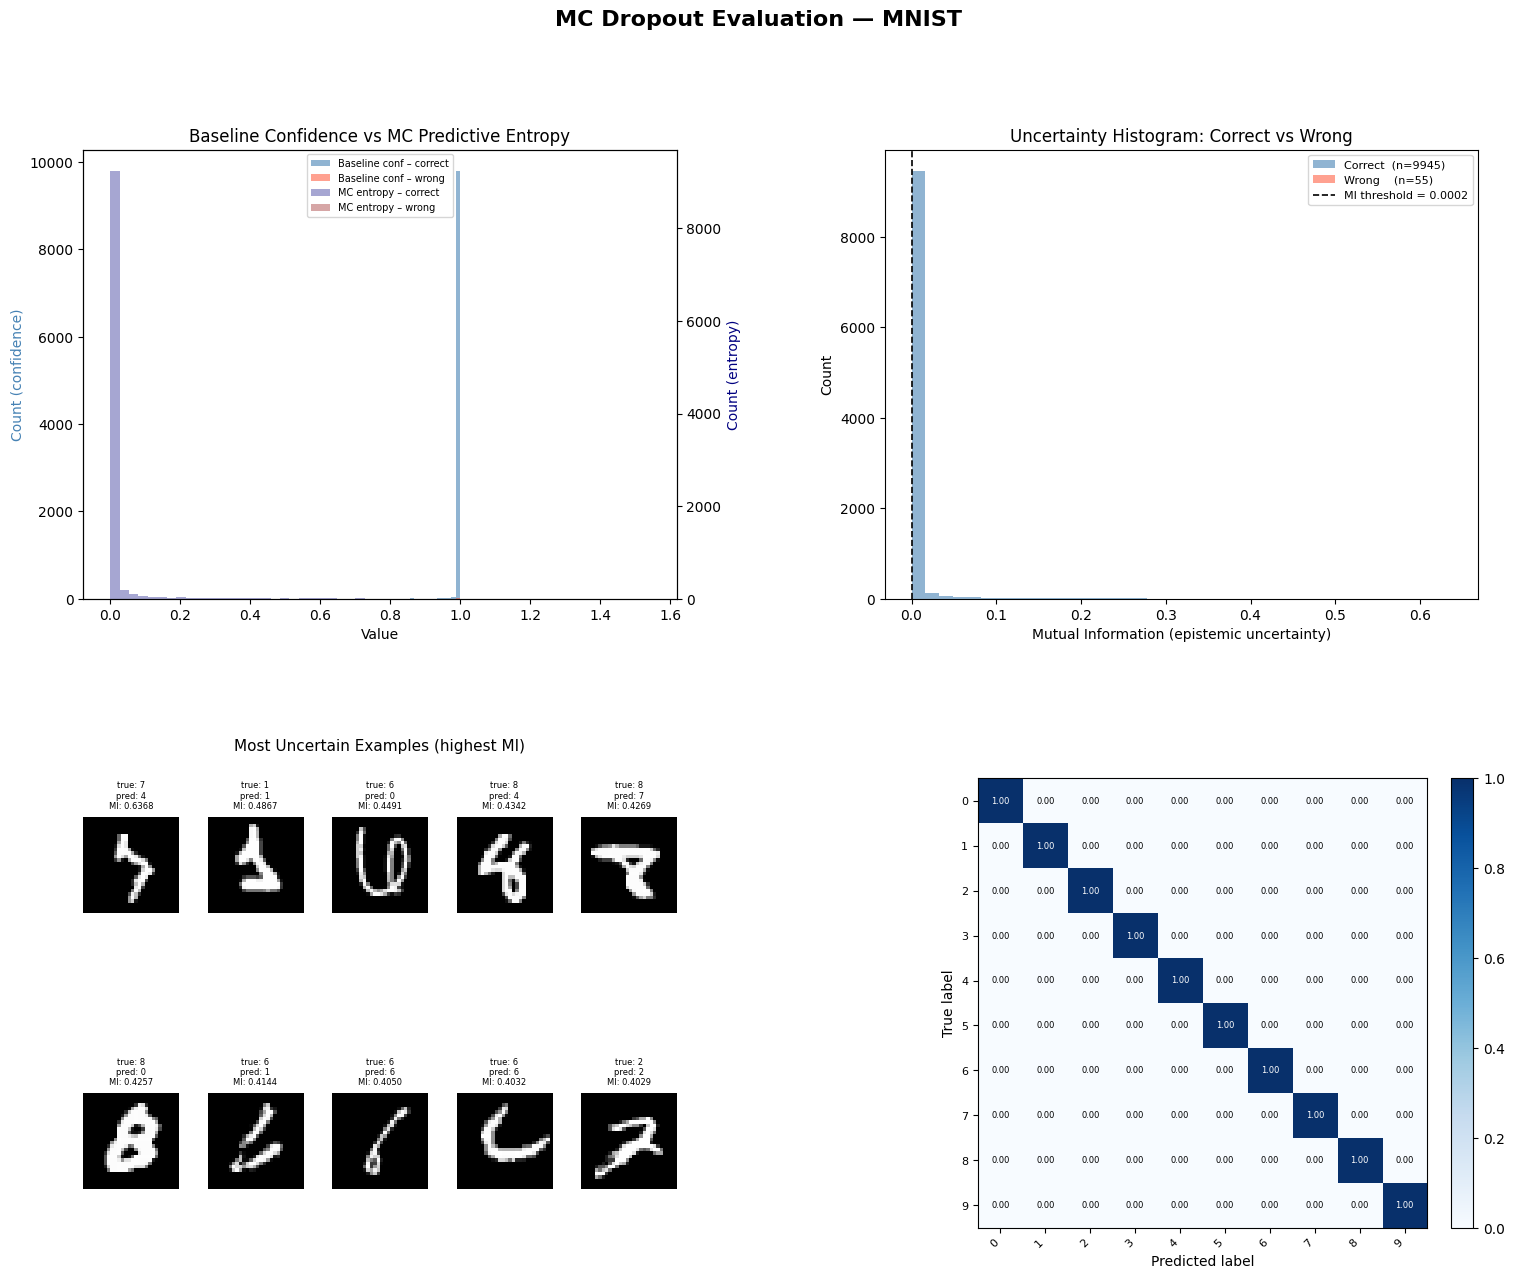

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import itertools

def confusion_matrix(y_true, y_pred, labels):
    n = len(labels)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t][p] += 1
    return cm


# Configuration

class Config:
    def __init__(self):
        self.lr           = 1e-3
        self.weight_decay = 1e-4
        self.epochs       = 20
        self.batch_size   = 128

cfg = Config()


# Data (MNIST)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train   = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(full_train, [55000, 5000])

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False)

C           = 1    # grayscale
K           = 10   # digits 0-9
class_names = [str(i) for i in range(10)]
device      = 'cuda' if torch.cuda.is_available() else 'cpu'


# MC Dropout CNN


class MCDropoutCNN(nn.Module):
    """
    CNN with dropout after each conv block and in the head.
    Mirrors BaselineCNN spatial dims: 28->14->7->3 via MaxPool2d(2).
    Output: logits [B, K]
    """
    def __init__(self, in_channels: int, num_classes: int, p_drop: float = 0.2):
        super().__init__()
        self.p_drop = p_drop

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 28 -> 14
            nn.Dropout2d(p=p_drop),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 14 -> 7
            nn.Dropout2d(p=p_drop),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 7 -> 3
            nn.Dropout2d(p=p_drop),
        )
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=p_drop),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        return self.head(x)


# Training & evaluation


def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()
        bs              = xb.size(0)
        total_loss     += loss.item() * bs
        total_correct  += (logits.argmax(1) == yb).sum().item()
        total_samples  += bs
    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits  = model(xb)
        loss    = F.cross_entropy(logits, yb)
        bs      = xb.size(0)
        total_loss    += loss.item() * bs
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_samples += bs
    return total_loss / total_samples, total_correct / total_samples

# MC Dropout inference utilities


def enable_dropout(model: nn.Module) -> None:
    """
    Keep dropout layers stochastic at inference time.
    Call AFTER model.eval() so BatchNorm stays in eval mode.
    """
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model: nn.Module, loader, T: int):
    """
    T stochastic forward passes per batch.

    Returns
    -------
    probs_mean : [N, K]   predictive mean  p̄(y|x)
    y          : [N]      true labels
    extras     : dict
        "predictive_entropy"  [N]    H[p̄]               – total uncertainty
        "expected_entropy"    [N]    E_t[H[p_t]]         – aleatoric uncertainty
        "mutual_information"  [N]    H[p̄] − E_t[H[p_t]] – epistemic uncertainty
        "probs_std"           [N, K] per-class std across T samples
    """
    model.eval()
    enable_dropout(model)

    probs_mean_list, pred_H_list, exp_H_list, mi_list, std_list, y_list = [], [], [], [], [], []

    for xb, yb in loader:
        xb = xb.to(device)

        # T stochastic forward passes  →  [T, B, K]
        probs_T = torch.stack(
            [F.softmax(model(xb), dim=-1) for _ in range(T)], dim=0
        )

        probs_mean = probs_T.mean(dim=0)                                        # [B, K]

        eps    = 1e-8
        H_pred = -(probs_mean * (probs_mean + eps).log()).sum(dim=-1)           # [B]
        H_each = -(probs_T    * (probs_T    + eps).log()).sum(dim=-1)           # [T, B]
        H_exp  = H_each.mean(dim=0)                                             # [B]
        MI     = H_pred - H_exp                                                 # [B]
        std    = probs_T.std(dim=0)                                             # [B, K]

        probs_mean_list.append(probs_mean.cpu())
        pred_H_list.append(H_pred.cpu())
        exp_H_list.append(H_exp.cpu())
        mi_list.append(MI.cpu())
        std_list.append(std.cpu())
        y_list.append(yb.cpu())

    probs_mean = torch.cat(probs_mean_list, dim=0)
    y          = torch.cat(y_list, dim=0)
    extras = {
        "predictive_entropy": torch.cat(pred_H_list, dim=0),
        "expected_entropy":   torch.cat(exp_H_list,  dim=0),
        "mutual_information": torch.cat(mi_list,     dim=0),
        "probs_std":          torch.cat(std_list,    dim=0),
    }
    return probs_mean, y, extras


@torch.no_grad()
def baseline_predict(model: nn.Module, loader):
    """
    Single deterministic pass (dropout OFF) for comparison.
    """
    model.eval()
    probs_list, y_list = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        probs_list.append(F.softmax(model(xb), dim=-1).cpu())
        y_list.append(yb.cpu())
    return torch.cat(probs_list, dim=0), torch.cat(y_list, dim=0)


# Evaluation & plotting


def evaluate_and_plot(
    mc_probs:         torch.Tensor,   # [N, K]
    mc_y:             torch.Tensor,   # [N]
    extras:           dict,
    base_probs:       torch.Tensor,   # [N, K]
    class_names:      list  = None,
    n_most_uncertain: int   = 10,
    mi_threshold:     float = None,
    test_loader             = None,
    save_path:        str   = "mc_dropout_mnist_evaluation.png",
):
    """
    Four-panel figure:
      1. Baseline softmax confidence vs MC predictive entropy
      2. Uncertainty histograms — correct vs wrong
      3. Most uncertain examples (highest MI)
      4. Confusion matrix conditioned on MI < threshold
    """
    N, K = mc_probs.shape
    if class_names is None:
        class_names = [str(i) for i in range(K)]

    preds        = mc_probs.argmax(dim=-1)
    correct_mask = (preds == mc_y).numpy()

    mi        = extras["mutual_information"].numpy()
    H         = extras["predictive_entropy"].numpy()
    base_conf = base_probs.max(dim=-1).values.numpy()

    if mi_threshold is None:
        mi_threshold = float(np.percentile(mi, 75))

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("MC Dropout Evaluation — MNIST", fontsize=16, fontweight="bold", y=0.98)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # ── Panel 1: Baseline confidence vs MC predictive entropy ────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(base_conf[correct_mask],  bins=50, alpha=0.6, color="steelblue", label="Baseline conf – correct")
    ax1.hist(base_conf[~correct_mask], bins=50, alpha=0.6, color="tomato",    label="Baseline conf – wrong")
    ax1b = ax1.twinx()
    ax1b.hist(H[correct_mask],  bins=50, alpha=0.35, color="navy",    label="MC entropy – correct")
    ax1b.hist(H[~correct_mask], bins=50, alpha=0.35, color="darkred", label="MC entropy – wrong")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Count (confidence)", color="steelblue")
    ax1b.set_ylabel("Count (entropy)",   color="navy")
    ax1.set_title("Baseline Confidence vs MC Predictive Entropy")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax1b.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper center")

    # ── Panel 2: MI histograms correct vs wrong ───────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    bins = np.linspace(mi.min(), mi.max(), 40)
    ax2.hist(mi[correct_mask],  bins=bins, alpha=0.6, color="steelblue", label=f"Correct  (n={correct_mask.sum()})")
    ax2.hist(mi[~correct_mask], bins=bins, alpha=0.6, color="tomato",    label=f"Wrong    (n={(~correct_mask).sum()})")
    ax2.axvline(mi_threshold, color="black", linestyle="--", linewidth=1.2,
                label=f"MI threshold = {mi_threshold:.4f}")
    ax2.set_xlabel("Mutual Information (epistemic uncertainty)")
    ax2.set_ylabel("Count")
    ax2.set_title("Uncertainty Histogram: Correct vs Wrong")
    ax2.legend(fontsize=8)

    # ── Panel 3: Most uncertain examples ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    top_idx = np.argsort(mi)[-n_most_uncertain:][::-1]

    if test_loader is not None:
        imgs = torch.cat([xb for xb, _ in test_loader], dim=0)   # [N, 1, 28, 28]
        n_cols = min(n_most_uncertain, 5)
        n_rows = int(np.ceil(n_most_uncertain / n_cols))
        ax3.axis("off")
        inner = gridspec.GridSpecFromSubplotSpec(
            n_rows, n_cols, subplot_spec=gs[1, 0], hspace=0.6, wspace=0.3
        )
        for plot_i, data_i in enumerate(top_idx[:n_most_uncertain]):
            ax = fig.add_subplot(inner[plot_i // n_cols, plot_i % n_cols])
            ax.imshow(imgs[data_i].squeeze().numpy(), cmap="gray")
            ax.set_title(
                f"true: {class_names[mc_y[data_i]]}\n"
                f"pred: {class_names[preds[data_i]]}\n"
                f"MI: {mi[data_i]:.4f}",
                fontsize=6,
            )
            ax.axis("off")
        ax3.set_title("Most Uncertain Examples (highest MI)", pad=20, fontsize=11)
    else:
        ax3.barh(range(n_most_uncertain), mi[top_idx], color="tomato")
        ax3.set_yticks(range(n_most_uncertain))
        ax3.set_yticklabels(
            [f"idx {i} | true:{class_names[mc_y[i]]} pred:{class_names[preds[i]]}"
             for i in top_idx], fontsize=7
        )
        ax3.set_xlabel("Mutual Information")
        ax3.set_title(f"Top-{n_most_uncertain} Most Uncertain Samples")
        ax3.invert_yaxis()

    # ── Panel 4: Confusion matrix on confident subset ────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    confident_mask = mi < mi_threshold
    n_confident    = confident_mask.sum()

    cm      = confusion_matrix(mc_y[confident_mask].numpy(), preds[confident_mask].numpy(), labels=list(range(K)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    im = ax4.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    ticks = np.arange(K)
    ax4.set_xticks(ticks); ax4.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax4.set_yticks(ticks); ax4.set_yticklabels(class_names, fontsize=8)
    thresh = cm_norm.max() / 2.0
    for i, j in itertools.product(range(K), range(K)):
        ax4.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                 fontsize=6, color="white" if cm_norm[i, j] > thresh else "black")
    ax4.set_ylabel("True label")
    ax4.set_xlabel("Predicted label")
    confident_acc = (preds[confident_mask] == mc_y.numpy()[confident_mask]).mean()
    ax4.set_title(
        f"Confusion Matrix | MI < {mi_threshold:.4f}\n"
        f"({n_confident}/{N} samples, acc = {confident_acc:.3f})"
    )

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")

    # ── Console summary ───────────────────────────────────────────────────────
    print("\n── Uncertainty Summary ──────────────────────────────────────────")
    print(f"  Overall accuracy              : {correct_mask.mean():.4f}")
    print(f"  Mean MI  – correct samples    : {mi[correct_mask].mean():.4f}")
    print(f"  Mean MI  – wrong   samples    : {mi[~correct_mask].mean():.4f}")
    print(f"  Mean H   – correct samples    : {H[correct_mask].mean():.4f}")
    print(f"  Mean H   – wrong   samples    : {H[~correct_mask].mean():.4f}")
    print(f"  MI threshold (75th pct)       : {mi_threshold:.4f}")
    print(f"  Samples below threshold       : {n_confident}/{N} ({100*n_confident/N:.1f}%)")
    print(f"  Accuracy on confident subset  : {confident_acc:.4f}")
    print("────────────────────────────────────────────────────────────────")


# Run


print(f"Using device: {device}")

mc_model  = MCDropoutCNN(C, K, p_drop=0.2).to(device)
optimizer = torch.optim.AdamW(mc_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

print("Training MC Dropout CNN on MNIST...")
for epoch in range(cfg.epochs):
    tr_loss, tr_acc = train_one_epoch(mc_model, train_loader, optimizer)
    va_loss, va_acc = evaluate(mc_model, val_loader)
    print(f"Epoch {epoch+1:02d}/{cfg.epochs} | tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | va_loss={va_loss:.4f} va_acc={va_acc:.4f}")

print("\nRunning MC inference (T=30)...")
mc_probs, mc_y, mc_extras = mc_dropout_predict(mc_model, test_loader, T=30)

print("Running deterministic baseline inference...")
base_probs, _ = baseline_predict(mc_model, test_loader)

print("\nGenerating evaluation plots...")
evaluate_and_plot(
    mc_probs, mc_y, mc_extras,
    base_probs   = base_probs,
    class_names  = class_names,
    mi_threshold = None,         # auto: 75th percentile
    test_loader  = test_loader,
)

Based on the results, training and validation loss decreases steadily with each epoch, while training and validation accuracy increases.